In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
wine_df=pd.read_csv('/content/WineQT.csv', index_col='Id')
wine_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
Id,,,,,,,,,,,,
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
wine_df.shape

(1143, 12)

In [ ]:
wine_df.info()
wine_df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 1143 entries, 0 to 1597
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 116.1 KB


,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [ ]:
wine_df['quality'].unique()

array([5, 6, 7, 4, 8, 3])

In [ ]:
wine_df.duplicated()
wine_df.drop_duplicates(inplace=True)
wine_df.shape

(1018, 12)

/tmp/ipykernel_1666/2406662144.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=wine_df['quality'], palette='viridis')


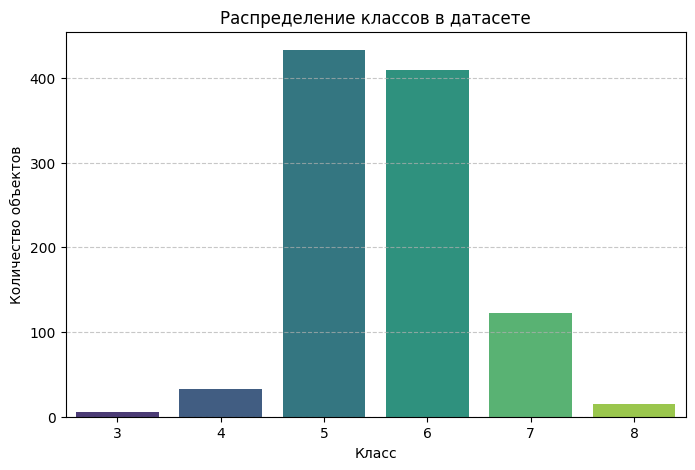

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x=wine_df['quality'], palette='viridis')

plt.title('Распределение классов в датасете')
plt.xlabel('Класс')
plt.ylabel('Количество объектов')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

датасет 1018 на 12, 11 числовых признаков и интовый таргет, без пропусков, преобладают 5 и 6 классы, щас посмотрим на матрицу корреляций и узнаем, есть ли проблемные признаки

In [ ]:
wine_df.corr()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.236894,0.668178,0.173726,0.102446,-0.152582,-0.100716,0.683120,-0.692597,0.181277,-0.077624,0.115826
volatile acidity,-0.236894,1.000000,-0.542459,-0.008701,0.051371,-0.007556,0.071870,0.028614,0.226348,-0.280601,-0.207419,-0.409340
citric acid,0.668178,-0.542459,1.000000,0.178362,0.246843,-0.048523,0.047903,0.368832,-0.553370,0.347933,0.102134,0.241565
residual sugar,0.173726,-0.008701,0.178362,1.000000,0.058410,0.146929,0.188528,0.363112,-0.120993,0.006738,0.070779,0.022718
chlorides,0.102446,0.051371,0.246843,0.058410,1.000000,0.014612,0.044947,0.210932,-0.277536,0.392989,-0.234283,-0.122214
free sulfur dioxide,-0.152582,-0.007556,-0.048523,0.146929,0.014612,1.000000,0.661089,-0.049664,0.051018,0.031844,-0.060876,-0.071083
total sulfur dioxide,-0.100716,0.071870,0.047903,0.188528,0.044947,0.661089,1.000000,0.053496,-0.071037,0.004963,-0.197917,-0.182214
density,0.683120,0.028614,0.368832,0.363112,0.210932,-0.049664,0.053496,1.000000,-0.366173,0.138789,-0.504748,-0.185187
pH,-0.692597,0.226348,-0.553370,-0.120993,-0.277536,0.051018,-0.071037,-0.366173,1.000000,-0.192979,0.230655,-0.057592
sulphates,0.181277,-0.280601,0.347933,0.006738,0.392989,0.031844,0.004963,0.138789,-0.192979,1.000000,0.096239,0.257519


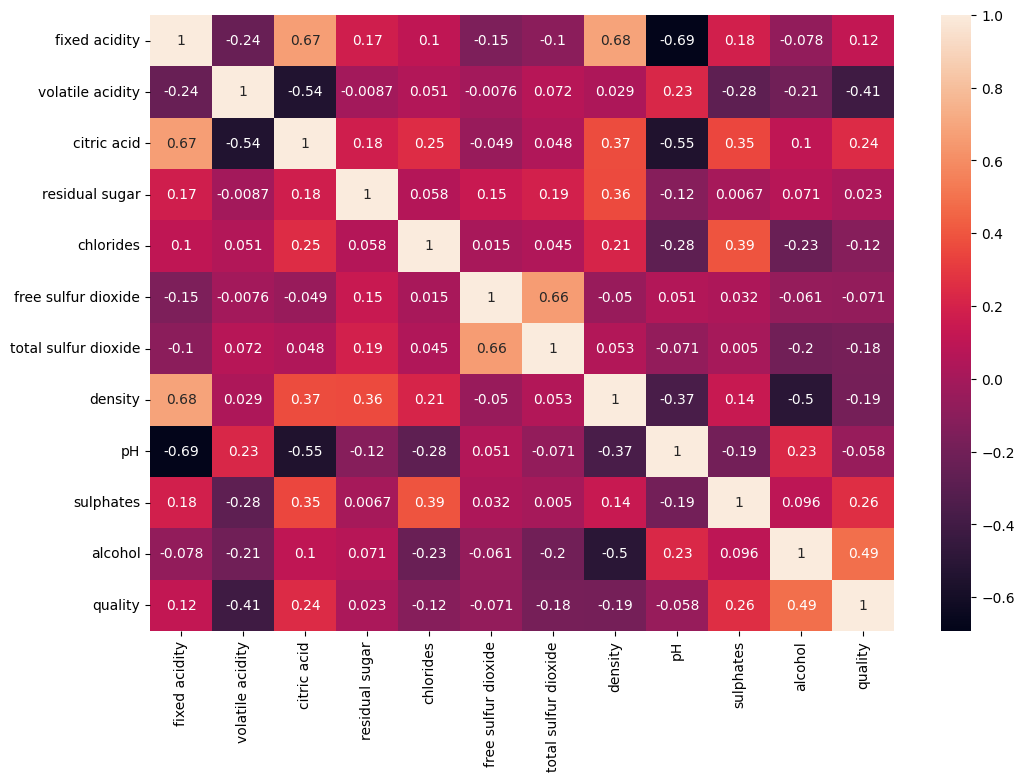

In [ ]:
plt.figure(figsize=(12, 8))

sns.heatmap(wine_df.corr(), annot=True)
plt.show()
wine_df.drop(['residual sugar', 'free sulfur dioxide', 'pH'], axis=1, inplace=True)

и удаляю ненужные признаки

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train, X_test, y_train, y_test = train_test_split(wine_df.drop('quality', axis=1).values, wine_df['quality'].values, test_size=0.2, random_state=42)
X_train_scaled, X_test_scaled = scaler.fit_transform(X_train), scaler.transform(X_test)
X_scaled=scaler.fit_transform(wine_df.drop('quality', axis=1).values)
y=wine_df['quality'].values

здесь мы
1. нормируем значения (чтобы уравновесить ценность признаков)
2. делим на train test


почему важно масштабирование (нормирование)?
потому что без него может случится такое, что один признак принимает значения 10000-20000, а другой 0-1, тогда получится, что на расстояние между объектами будет влиять только первый признак, а значения второго вообщне не важны

почему нельзя выбирать параметры на тесте?
потому что тогда она превращается во второй треин, и не получится сравнить результаты предсказания модели

In [ ]:
from sklearn.metrics import accuracy_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {'n_neighbors': [3, 5, 7, 9, 11, 15], 'p': [1, 2, 3, np.inf]}
grid_knn=GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')
grid_knn.fit(X_train_scaled, y_train)
best_knn_params=grid_knn.best_params_
best_knn=grid_knn.best_estimator_
best_knn.fit(X_train_scaled, y_train)
y_pred=best_knn.predict(X_test_scaled)


quality_scores=[accuracy_score(y_pred=y_pred, y_true=y_test), f1_score(y_pred=y_pred, y_true=y_test, average='weighted')]
quality_df=pd.DataFrame(quality_scores, index=['Accuracy', 'F1'])


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


здесь используем кросс-валидацию и отбираем лучшую модель, смотрим ее метрики качества

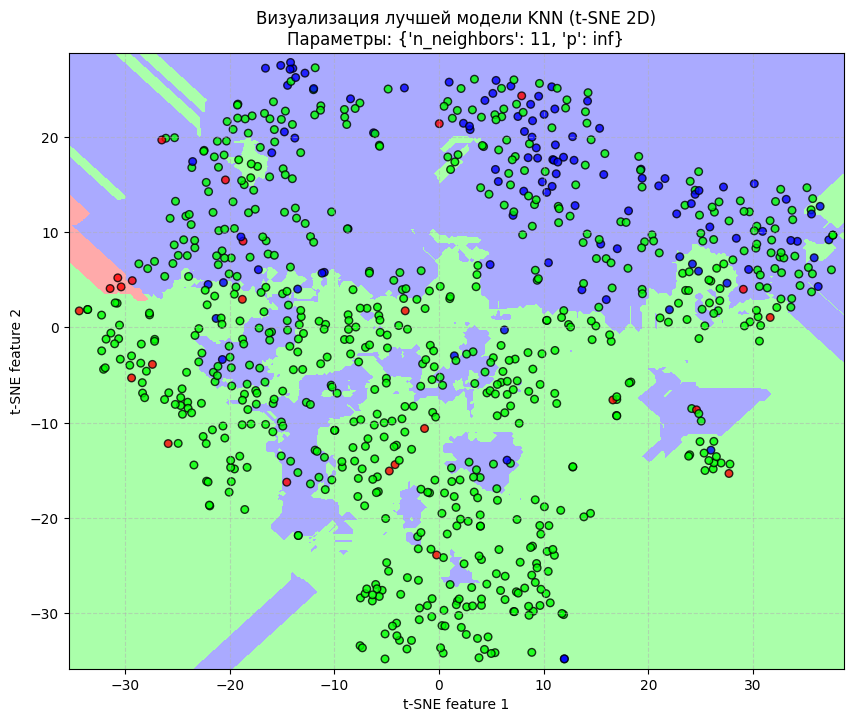

Сводная таблица качества:


,0
Accuracy,0.553922
F1,0.525650


In [ ]:
from matplotlib.colors import ListedColormap
from sklearn.manifold import TSNE

X_train_embedded, X_test_embedded = TSNE(n_components=2, random_state=42).fit_transform(X_train_scaled), TSNE(n_components=2, random_state=42).fit_transform(X_test_scaled)

best_vis_model = KNeighborsClassifier(**grid_knn.best_params_)
best_vis_model.fit(X_train_embedded, y_train)

h = .05
x_min, x_max = X_train_embedded[:, 0].min() - 1, X_train_embedded[:, 0].max() + 1
y_min, y_max = X_train_embedded[:, 1].min() - 1, X_train_embedded[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = best_vis_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

plt.figure(figsize=(10, 8))
plt.pcolormesh(xx, yy, Z, cmap=cmap_light, shading='auto')

plt.scatter(X_train_embedded[:, 0], X_train_embedded[:, 1], c=y_train,
            cmap=cmap_bold, edgecolor='k', s=30, alpha=0.8)

plt.title(f"Визуализация лучшей модели KNN (t-SNE 2D)\nПараметры: {grid_knn.best_params_}")
plt.xlabel("t-SNE feature 1")
plt.ylabel("t-SNE feature 2")
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

print("Сводная таблица качества:")
display(quality_df)

понижаем размерность и визуализируем